<a href="https://colab.research.google.com/github/tnc1/ai-ml/blob/main/Day9_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
"""
  Smart E-Commerce Customer Segmentation

  SCENARIO

    An e-commerce company wants AI to analyze customer shopping behavior and automatically group customers into:
      Low Value Customers
      Medium Value Customers
      High Value Customers
      based on:
        Monthly Purchase Amount
        Website Visit Count

    The company also wants to compare AI-generated groups with known labels and understand:
      ✅ Accuracy
      ✅ Precision
      ✅ Recall

    This helps connect:
      K-Means Clustering
      Evaluation Metrics
      Real-world AI workflows
"""

'\n  Smart E-Commerce Customer Segmentation\n\n  SCENARIO\n\n    An e-commerce company wants AI to analyze customer shopping behavior and automatically group customers into:\n      Low Value Customers\n      Medium Value Customers\n      High Value Customers\n      based on:\n        Monthly Purchase Amount\n        Website Visit Count\n\n    The company also wants to compare AI-generated groups with known labels and understand:\n      ✅ Accuracy\n      ✅ Precision\n      ✅ Recall\n\n    This helps connect:\n      K-Means Clustering\n      Evaluation Metrics\n      Real-world AI workflows\n'


Original Dataset

   Purchase_Amount  Website_Visits  Actual_Label
0              500               2             0
1              700               3             0
2             1000               4             0
3             3000              10             1
4             4000              12             1
5             5000              15             1
6             9000              25             2
7            10000              28             2
8            12000              30             2

Predicted Clusters

[2 2 2 0 0 0 1 1 1]

Cluster Centers

[[4.00000000e+03 1.23333333e+01]
 [1.03333333e+04 2.76666667e+01]
 [7.33333333e+02 3.00000000e+00]]

Updated Dataset

   Purchase_Amount  Website_Visits  Actual_Label  Predicted  Mapped_Predicted  \
0              500               2             0          2                 0   
1              700               3             0          2                 0   
2             1000               4             0          2            

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


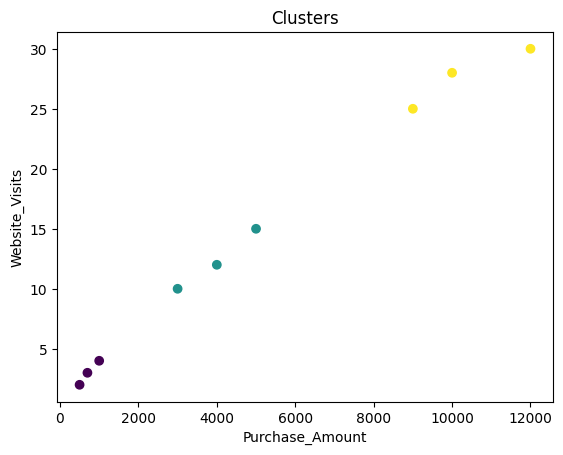

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

# ============================================
# Create Dataset
# ============================================

data = {

'Purchase_Amount':
[500,700,1000,
3000,4000,5000,
9000,10000,12000],


'Website_Visits':
[2,3,4,
10,12,15,
25,28,30],


'Actual_Label':
[0,0,0,
1,1,1,
2,2,2]
}

df = pd.DataFrame(data)

print("\nOriginal Dataset\n")

print(df)


# ============================================
# Select Input Features
# ============================================

X = df[['Purchase_Amount','Website_Visits']]


# ============================================
# Train K-Means
# ============================================

model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(X)


# ============================================
# Predict Clusters
# ============================================

predicted = model.labels_

df['Predicted'] = predicted


print("\nPredicted Clusters\n")

print(predicted)


# ============================================
# IMPORTANT:
# K-Means labels are random
# ============================================

print("\nCluster Centers\n")

print(model.cluster_centers_)


# Actual learned clusters:

# Cluster 2 → Low
# Cluster 0 → Medium
# Cluster 1 → High

cluster_mapping = {

2:0,
0:1,
1:2

}


df['Mapped_Predicted'] = (
    df['Predicted']
    .map(cluster_mapping)
)


# Human-friendly labels

activity_map = {

0:'Low Value Customer',
1:'Medium Value Customer',
2:'High Value Customer'

}


df['Level']=(
    df['Mapped_Predicted']
    .map(activity_map)
)


print("\nUpdated Dataset\n")

print(df)


# ============================================
# Evaluation
# ============================================

accuracy = accuracy_score(

    df['Purchase_Amount'],

    df['Website_Visits']

)


precision = precision_score(

    df['Purchase_Amount'],

    df['Website_Visits'],

    average='macro'

)


recall = recall_score(

    df['Actual_Label'],

    df['Mapped_Predicted'],

    average='macro'

)


print("\nAccuracy:",accuracy)

print("Precision:",precision)

print("Recall:",recall)


# ============================================
# Visualization
# ============================================

plt.scatter(

    df['Purchase_Amount'],

    df['Website_Visits'],

    c=df['Mapped_Predicted']

)

plt.xlabel("Purchase_Amount")

plt.ylabel("Website_Visits")

plt.title(
    "Clusters"
)

plt.show()